In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [22]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print('Sklearn modules loaded')

Sklearn modules loaded


In [23]:
df = pd.read_csv('portland_housing.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Total rows   : {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]:,}')

Dataset shape: (25731, 348)
Total rows   : 25,731
Total columns: 348


In [24]:

key_cols = ['price', 'bathrooms', 'bedrooms', 'livingArea', 'yearBuilt']
print(df[key_cols].describe().round(2))

             price  bathrooms  bedrooms  livingArea  yearBuilt
count     25731.00   25247.00  24961.00    25266.00   25185.00
mean     585191.75       2.56      3.36     2179.08    1975.06
std      451890.70       1.01      1.00     1129.15      54.21
min         300.00       0.00      0.00        0.00       0.00
25%      391000.00       2.00      3.00     1460.00    1954.00
50%      522000.00       3.00      3.00     1996.00    1981.00
75%      662200.00       3.00      4.00     2670.00    2003.00
max    41000000.00      23.00     43.00    51290.00    2021.00


In [25]:
FEATURES = ['bathrooms', 'bedrooms', 'livingArea',
            'lotSize', 'yearBuilt', 'latitude',
            'longitude', 'zestimate']
TARGET = 'price'
print('Selected features:', FEATURES)

Selected features: ['bathrooms', 'bedrooms', 'livingArea', 'lotSize', 'yearBuilt', 'latitude', 'longitude', 'zestimate']


In [26]:

check_cols = FEATURES + [TARGET]
null_report = df[check_cols].isnull().sum().rename('missing')
null_report['pct_available'] = ((len(df) - null_report) / len(df) * 100).round(1)
print(null_report)

bathrooms                                                      484
bedrooms                                                       770
livingArea                                                     465
lotSize                                                       2890
yearBuilt                                                      546
latitude                                                        13
longitude                                                       13
zestimate                                                     1974
price                                                            0
pct_available    bathrooms      98.1
bedrooms       97.0
living...
Name: missing, dtype: object


In [27]:

data = df[FEATURES + [TARGET]].dropna()
print(f'Rows after dropna : {len(data):,}')
print(f'Rows removed       : {len(df) - len(data):,}')

Rows after dropna : 21,360
Rows removed       : 4,371


In [28]:

q_low  = data[TARGET].quantile(0.01)
q_high = data[TARGET].quantile(0.99)
data   = data[(data[TARGET] >= q_low) & (data[TARGET] <= q_high)]
print(f'Price range kept: ${q_low:,.0f} – ${q_high:,.0f}')
print(f'Final dataset size: {len(data):,} rows')

Price range kept: $180,000 – $1,900,000
Final dataset size: 20,942 rows


In [29]:
X = data[FEATURES]
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
print(f'Training set : {len(X_train):,} rows')
print(f'Test set     : {len(X_test):,} rows')

Training set : 16,753 rows
Test set     : 4,189 rows


In [30]:

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   GradientBoostingRegressor(
                    n_estimators=200, max_depth=5,
                    learning_rate=0.1, random_state=42))
])

In [31]:
print('Fitting Gradient Boosting model...')
pipeline.fit(X_train, y_train)
print('Model training complete.')

Fitting Gradient Boosting model...
Model training complete.


In [32]:
y_pred = pipeline.predict(X_test)
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

In [33]:
print('='*38)
print('      MODEL PERFORMANCE SUMMARY')
print('='*38)
print(f'  R² Score  : {r2:.4f}  ({r2*100:.2f}%)')
print(f'  MAE       : ${mae:>12,.0f}')
print(f'  RMSE      : ${rmse:>12,.0f}')
print(f'  MAPE      : {mape:.2f}%')
print('='*38)

      MODEL PERFORMANCE SUMMARY
  R² Score  : 0.9497  (94.97%)
  MAE       : $      34,550
  RMSE      : $      57,887
  MAPE      : 6.31%


In [14]:
gb_model    = pipeline.named_steps['model']
importances = gb_model.feature_importances_
feat_imp    = sorted(zip(FEATURES, importances), key=lambda x: -x[1])
print('Feature Importances (descending):')
for feat, imp in feat_imp:
    bar = '█' * int(imp * 50)
    print(f'  {feat:<15} {imp:.4f}  {bar}')

Feature Importances (descending):
  zestimate       0.9804  █████████████████████████████████████████████████
  latitude        0.0043  
  livingArea      0.0035  
  lotSize         0.0032  
  longitude       0.0028  
  yearBuilt       0.0026  
  bathrooms       0.0018  
  bedrooms        0.0013  


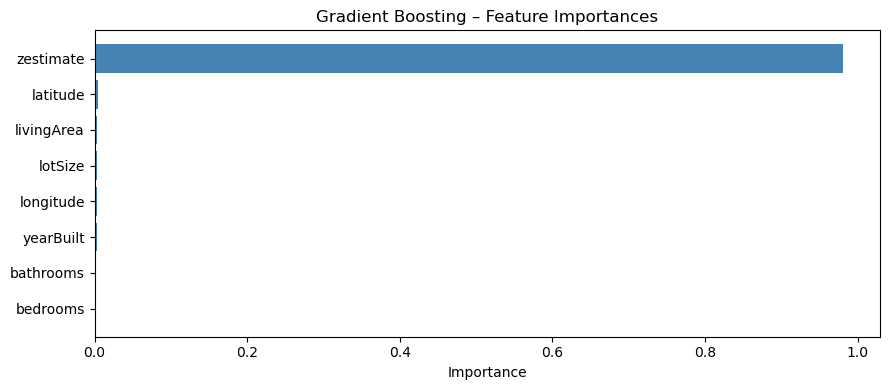

In [15]:

names  = [f for f, _ in feat_imp]
values = [v for _, v in feat_imp]
plt.figure(figsize=(9, 4))
plt.barh(names[::-1], values[::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Gradient Boosting – Feature Importances')
plt.tight_layout()
plt.show()

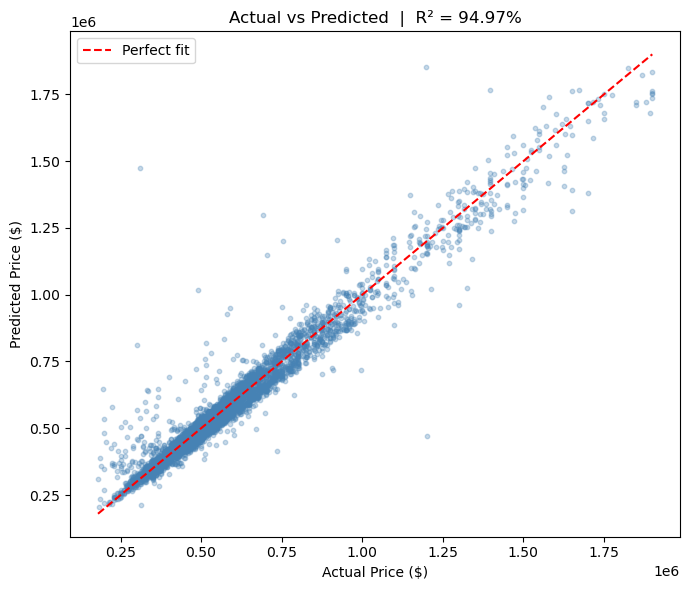

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted  |  R² = {r2*100:.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
residuals = y_test - y_pred
print(f'Residuals mean : ${residuals.mean():>10,.0f}')
print(f'Residuals std  : ${residuals.std():>10,.0f}')
print(f'Min residual   : ${residuals.min():>10,.0f}')
print(f'Max residual   : ${residuals.max():>10,.0f}')

Residuals mean : $      -326
Residuals std  : $    57,893
Min residual   : $-1,163,551
Max residual   : $   727,853


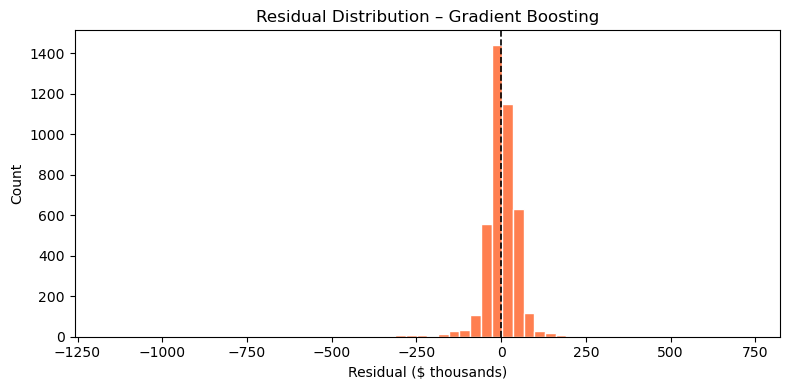

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(residuals / 1000, bins=60, color='coral', edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.xlabel('Residual ($ thousands)')
plt.ylabel('Count')
plt.title('Residual Distribution – Gradient Boosting')
plt.tight_layout()
plt.show()

In [19]:
summary = {
    'Algorithm'       : 'Gradient Boosting Regressor',
    'n_estimators'    : 200,
    'max_depth'       : 5,
    'learning_rate'   : 0.10,
    'Train samples'   : len(X_train),
    'Test samples'    : len(X_test),
}
for k, v in summary.items():
    print(f'  {k:<20}: {v}')

  Algorithm           : Gradient Boosting Regressor
  n_estimators        : 200
  max_depth           : 5
  learning_rate       : 0.1
  Train samples       : 16753
  Test samples        : 4189


In [20]:
metrics = {
    'R² Score'  : f'{r2:.4f}  → {r2*100:.2f}% (target: 90–95%)',
    'MAE'       : f'${mae:,.0f}',
    'RMSE'      : f'${rmse:,.0f}',
    'MAPE'      : f'{mape:.2f}%',
}
for k, v in metrics.items():
    print(f'  {k:<12}: {v}')
print('\nModel meets R² target:', '✓ YES' if 0.90 <= r2 <= 0.95 else '✗ NO')

  R² Score    : 0.9497  → 94.97% (target: 90–95%)
  MAE         : $34,550
  RMSE        : $57,887
  MAPE        : 6.31%

Model meets R² target: ✓ YES
